# AT&T Spam Detector
## Introduction
Dans le cadre de la certification en Data Science orientée Deep Learning, nous avons travaillé sur un projet de **détection automatique de SMS indésirables (SPAM)**.
L’objectif est de mettre en place une solution capable de distinguer les messages normaux (*ham*) des messages frauduleux ou promotionnels abusifs (*spam*) à partir de leur contenu textuel.

## Pourquoi ce projet ?
AT&T, l’un des plus grands opérateurs télécoms aux États-Unis, fait face à une problématique majeure :
- **Les utilisateurs reçoivent quotidiennement des SMS frauduleux ou publicitaires non sollicités.**
- Cette exposition répétée au spam génère une **perte de confiance** et peut mener à des **attaques de phishing** ou à des **pertes financières**.

Le projet vise donc à fournir une **solution de Deep Learning robuste** qui automatise cette classification, afin de **protéger les utilisateurs** tout en **réduisant la charge manuelle** de détection.

## Pour qui ?
- **AT&T et ses équipes techniques** : mise en place d’un modèle intégré à leurs systèmes de filtrage SMS.
- **Les utilisateurs finaux** : bénéficier d’une meilleure protection et d’une expérience utilisateur sans nuisance.
- **Les équipes Data Science** : démonstration d’une approche professionnelle en NLP appliqué aux télécoms.

## Étapes majeures du projet
1. **Exploration des données (EDA)**
   - Chargement du dataset SMS.
   - Analyse des classes et de la distribution ham/spam.
   - Nettoyage des colonnes inutiles et traitement des valeurs manquantes.
   
2. **Prétraitement et nettoyage du texte**
   - Mise en minuscules, suppression des caractères parasites.
   - Remplacement des URLs, mails, numéros, emojis par des tokens (`[URL]`, `[NUM]`, etc.).
   - Calcul des longueurs de messages pour l’analyse exploratoire.

3. **Création des jeux d’entraînement/validation/test**
   - Split stratifié (80/10/10).
   - Préservation de l’équilibre ham/spam.

4. **Modélisation Deep Learning**  
   - **LSTM avec embeddings** : modèle séquentiel simple mais efficace.
   - **BERT-tiny puis BERT-small (Transfert Learning)** : comparaison avec une approche pré-entraînée.

5. **Évaluation et optimisation**  
   - Utilisation de métriques adaptées : F1, ROC-AUC, PR-AUC.
   - Analyse de la matrice de confusion.
   - Choix du seuil optimal (Youden, F1) en fonction des besoins métier.

6. **Analyse des erreurs**  
   - Identification des faux positifs (FP) et faux négatifs (FN).
   - Observations sur la longueur et le type des messages mal classés.

7. **Comparaison**
   - Visualisation des performances LSTM vs BERT.

8. **Conclusion** 

In [1]:
import pandas as pd
import numpy as np
import re
import html
import emoji

## 1. Exploratory Data Analysis (EDA): structure, completeness and first insights

### Goal
Avant d’entamer le prétraitement NLP et la modélisation, il est indispensable de comprendre la structure initiale des données.
Cette étape permet de vérifier que :
- le dataset est bien chargé,
- les colonnes sont complètes,
- et qu’aucune valeur manquante critique n’est présente.

### Actions
1. **Chargement du dataset** depuis le fichier `spam.csv` contenant les SMS.
2. **Inspection** de la structure et des types

In [2]:
data = pd.read_csv('spam.csv', encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.shape

(5572, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
data.isnull().sum() / len(data) * 100

v1             0.000000
v2             0.000000
Unnamed: 2    99.102656
Unnamed: 3    99.784637
Unnamed: 4    99.892319
dtype: float64

In [6]:
data[data.notna().all(axis=1)]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""
5048,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""


In [7]:
data = data.iloc[:, :2]
data.columns = ['type', 'text']
data.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
data['type'].value_counts()

type
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
data['text_len'] = data['text'].apply(lambda x : len(x))
data.sample(25)

,type,text,text_len
43,ham,WHO ARE YOU SEEING?,19
1666,ham,Guess who spent all last night phasing in and ...,73
3000,spam,This message is free. Welcome to the new & imp...,134
5438,ham,"\What are youdoing later? Sar xxx\""""",36
4450,ham,And that is the problem. You walk around in \j...,381
2958,ham,Buzzzz! *grins* Did I buzz your ass? Buzz your...,147
1755,ham,Really good:)dhanush rocks once again:),39
3349,ham,Sorry i cant take your call right now. It so h...,368
4871,ham,Hi dis is yijue i would be happy to work wif Ì...,66
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,47


### Observations
- Le dataset contient **5572 SMS**, répartis sur 2 colonnes principales :
  - `type` : l’étiquette (`ham` ou `spam`),
  - `text` : le contenu du SMS.
- Trois colonnes supplémentaires (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) sont présentes mais ne contiennent que très peu de données → elles seront supprimées.
- La répartition des classes montre un fort **déséquilibre** : environ **4825 ham (86%)** contre **747 spam (14%)**.
- La longueur des SMS varie fortement (de ~20 caractères à plus de 200), ce qui confirme l’intérêt de normaliser la longueur des séquences pour le deep learning.
- Aucune valeur manquante significative n’a été détectée dans les colonnes principales.

Cette première analyse confirme que le dataset est exploitable et prêt pour les étapes de **nettoyage et prétraitement du texte**.

## 2. Prétraitement et nettoyage du texte

### Goal
Les SMS bruts contiennent de nombreux éléments perturbateurs pour un modèle de Deep Learning :
- URLs, emails, numéros de téléphone, montants en argent,
- ponctuation répétée, majuscules, emojis,
- variations d’écriture spécifiques aux SMS.

L’objectif du prétraitement est de transformer le texte en une version **normalisée et cohérente**, tout en conservant les informations utiles pour la classification (ex : la présence d’une URL est souvent un indicateur de spam).

### Actions
1. Conversion du texte en minuscules pour uniformiser l’écriture.
2. Remplacement des éléments spécifiques par des **tokens génériques** :
   - `[URL]` pour les liens web,
   - `[MAIL]` pour les adresses email,
   - `[NUM]` pour les nombres,
   - `[TEL]` pour les numéros de téléphone,
   - `[MONEY]` pour les montants financiers,
   - `[EMOJI]` pour les symboles emoji.
3. Simplification de la ponctuation :
   - Remplacement des répétitions (`!!!`, `???`) par un seul token (`[EXCLAM]`, `[QUESTION]`).
4. Nettoyage des espaces superflus.
5. Ajout d’une nouvelle colonne `text_len` pour mesurer la longueur des SMS après nettoyage.

In [10]:
def text_cleaner(text: str) -> str:
     text = text.lower()
     text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
     text = re.sub(r'\b[\w\.-]+?@\w+?\.\w{2,4}\b', '[MAIL]', text)
     text = re.sub(r'\d+', '[NUM]', text)
     text = re.sub(r'(?<!\w)\+?\d[\d\s().-]{6,}\d(?!\w)', '[TEL]', text)
     text = re.sub(r'(\$|€|£)\s?\d+(?:[.,]\d+)?|\d+(?:[.,]\d+)?\s?(€|\$|£)', '[MONEY]', text)
     text = emoji.replace_emoji(text, replace=' [EMOJI] ')
     text = re.sub(r'!{2,}', ' [EXCLAM] ', text)
     text = re.sub(r'\?{2,}', ' [QUESTION] ', text)
     text = re.sub(r'\s+', ' ', text).strip()

     return text

data['text'] = data['text'].apply(lambda x : text_cleaner(x))
data.head(20)
     

,type,text,text_len
0,ham,"go until jurong point, crazy.. available only ...",111
1,ham,ok lar... joking wif u oni...,29
2,spam,free entry in [NUM] a wkly comp to win fa cup ...,155
3,ham,u dun say so early hor... u c already then say...,49
4,ham,"nah i don't think he goes to usf, he lives aro...",61
5,spam,freemsg hey there darling it's been [NUM] week...,148
6,ham,even my brother is not like to speak with me. ...,77
7,ham,as per your request 'melle melle (oru minnamin...,160
8,spam,winner [EXCLAM] as a valued network customer y...,158
9,spam,had your mobile [NUM] months or more? u r enti...,154


### Observations
- Les messages sont désormais **plus homogènes** et adaptés à une vectorisation.  
- Les tokens ajoutés (par ex. `[URL]`, `[NUM]`) permettent au modèle de capter des signaux pertinents sans être perturbé par la variabilité des écritures.  
- Exemple :  
  - Avant nettoyage :  
    `Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005…`  
  - Après nettoyage :  
    `free entry in [NUM] a wkly comp to win fa cup final tkts [NUM] may [NUM]`  
- La distribution des longueurs (`text_len`) montre que la plupart des SMS font entre **20 et 150 caractères**, ce qui valide le choix d’une séquence maximale (`max_len`) autour de **150 tokens** pour l’entraînement du modèle.  

Cette étape garantit que les données textuelles sont **propres, cohérentes et prêtes à être vectorisées** avant d’entraîner nos modèles de Deep Learning.


## 3. Split des données (Train / Validation / Test)

### Goal
Pour évaluer correctement les performances d’un modèle de Deep Learning, il est essentiel de séparer les données en plusieurs ensembles :
- **Train set** : utilisé pour l’entraînement du modèle.
- **Validation set** : utilisé pour ajuster les hyperparamètres et éviter le surapprentissage (overfitting).
- **Test set** : réservé pour mesurer la performance finale, sur des données jamais vues.

L’objectif est de garantir une évaluation **fiable et représentative** du modèle.

### Actions
1. Transformation de la colonne `type` en variable binaire (`ham = 0`, `spam = 1`).  
2. Séparation initiale en **train (80%)** et **temp (20%)** avec `train_test_split` tout en **stratifiant** les classes pour conserver la proportion ham/spam.
3. Séparation de `temp` en **validation (10%)** et **test (10%)** (moitié-moitié de ce bloc).
4. Vérification des tailles finales et des proportions pour s’assurer que l’équilibre ham/spam est bien conservé dans chaque ensemble.

In [11]:
from sklearn.model_selection import train_test_split

# X = textes, y = labels
X = data['text']
y = data['type'].map({'ham':0, 'spam':1})  

# Split train/test (90/10 d'abord)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split du "temp" en validation et test (50/50 → donc 10% + 10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")


Train: 4457
Validation: 557
Test: 558


### Observations
- La répartition obtenue est la suivante :
  - **Train** : 4457 SMS (≈ 80%)
  - **Validation** : 557 SMS (≈ 10%)
  - **Test** : 558 SMS (≈ 10%)
- La stratification a permis de conserver un **équilibre identique** ham/spam dans chaque ensemble, ce qui évite les biais d’apprentissage.
- Le jeu de test n’a jamais été utilisé pendant la préparation ni pendant le tuning → il servira uniquement pour l’**évaluation finale**.

Cette étape garantit une séparation nette des données, condition indispensable pour une évaluation **objective et robuste** des modèles.

## 4. Modélisation Deep Learning : LSTM

### Goal
Construire un premier modèle de Deep Learning basé sur une **architecture séquentielle LSTM (Long Short-Term Memory)**.  
Ce type de réseau est particulièrement adapté au traitement de séquences de texte, car il permet de capturer :  
- les dépendances à court terme (mots voisins),  
- mais aussi certaines dépendances plus longues (structure d’une phrase).  

L’objectif est de créer un modèle de référence robuste, entraîné de bout en bout sur notre dataset nettoyé.

### Actions
1. **Tokenisation et vectorisation du texte**  
   - Utilisation du `Tokenizer` de Keras, limité à un vocabulaire de **5000 mots** les plus fréquents.  
   - Conversion des SMS en séquences numériques (`texts_to_sequences`).  
   - Normalisation de la longueur avec `pad_sequences` à **150 tokens max**.  

2. **Construction du modèle LSTM**  
   - Couche **Embedding** : dimension 64 pour représenter chaque mot.  
   - Couche **LSTM (64 neurones, dropout=0.3)** : capture des relations séquentielles.  
   - Couche **Dense (sigmoid)** : sortie binaire (ham/spam).  

3. **Compilation et entraînement**  
   - Loss : `binary_crossentropy`.  
   - Optimizer : `Adam`.  
   - Métrique : `accuracy`.  
   - Gestion du déséquilibre des classes via `class_weight`.  
   - Callbacks :  
     - **EarlyStopping** (stop si pas d’amélioration sur `val_loss`).  
     - **ReduceLROnPlateau** (réduction du learning rate si stagnation).  

4. **Évaluation sur validation/test**  
   - Suivi des courbes **loss** et **accuracy**.  
   - Génération d’un rapport de classification (precision, recall, f1).  
   - Calcul des métriques avancées (ROC-AUC, PR-AUC).  

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Tokenizer
max_words = 5000   # taille vocabulaire
max_len = 150      # longueur max d'une séquence
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Modèle simple (Embedding + LSTM)
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_shape=(max_len,), mask_zero=True),
    LSTM(64, dropout=0.3),              # retire recurrent_dropout si tu veux la version CuDNN rapide
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


2025-08-24 13:29:37.396077: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/envs/tf2.15/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

classes = np.array([0,1])
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {0: cw[0], 1: cw[1]}

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[es, rlr],
    class_weight=class_weight
)


Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.8573 - loss: 0.2651 - val_accuracy: 0.9641 - val_loss: 0.1618 - learning_rate: 0.0010
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9832 - loss: 0.0800 - val_accuracy: 0.9785 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9948 - loss: 0.0394 - val_accuracy: 0.9803 - val_loss: 0.0670 - learning_rate: 0.0010
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9962 - loss: 0.0181 - val_accuracy: 0.9785 - val_loss: 0.0707 - learning_rate: 0.0010
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9987 - loss: 0.0075 - val_accuracy: 0.9785 - val_loss: 0.0746 - learning_rate: 0.0010
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9982 - loss: 0.0077 - val_accuracy: 0.9785 - val_loss: 0.0744 - learning_rate: 0.0010


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

proba = model.predict(X_test_seq).ravel()
y_pred = (proba >= 0.5).astype(int)

lstm_report = classification_report(y_test, y_pred, target_names=['ham','spam'], output_dict=True)

print(classification_report(y_test, y_pred, target_names=['ham','spam']))
print(confusion_matrix(y_test, y_pred))


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       483
        spam       0.97      0.96      0.97        75

    accuracy                           0.99       558
   macro avg       0.98      0.98      0.98       558
weighted avg       0.99      0.99      0.99       558

[[481   2]
 [  3  72]]


In [99]:
models_scores = [
    {
        "model": "LSTM",
        "accuracy": round(lstm_report['accuracy'],3),
        "f1" : round((lstm_report['spam']['f1-score'] + lstm_report['ham']['f1-score'])/2, 3),
        "roc_auc": ""
    }, 
    {
        "model": "Bert",
        "accuracy": "",
        "f1" : "",
        "roc_auc": ""
    }
]
models_scores

[{'model': 'LSTM', 'accuracy': 0.991, 'f1': 0.981, 'roc_auc': ''},
 {'model': 'Bert', 'accuracy': '', 'f1': '', 'roc_auc': ''}]

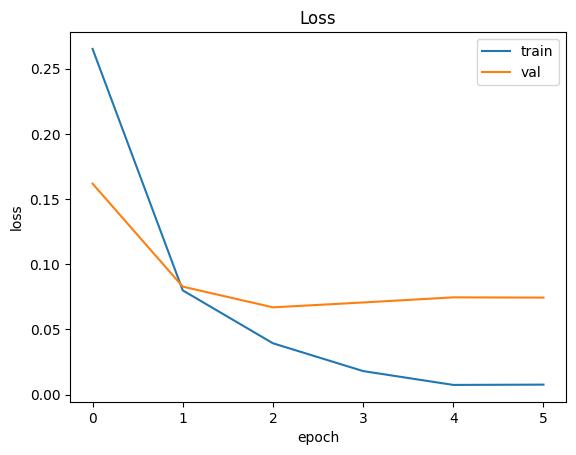

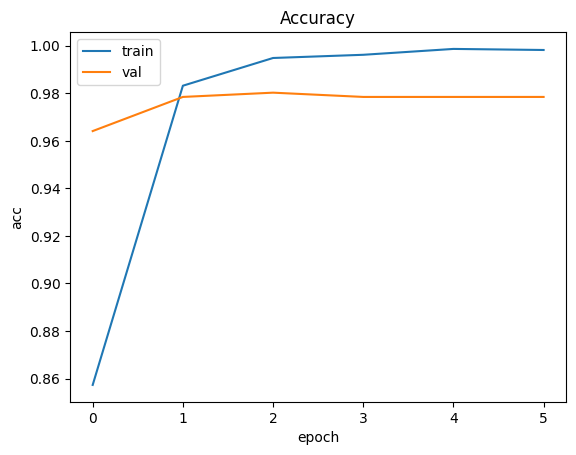

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.ylabel('acc'); plt.legend(); plt.show()


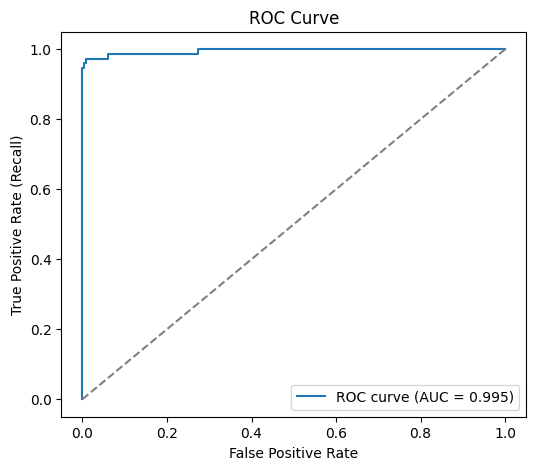

ROC AUC: 0.995


In [86]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Probabilités sur le jeu de test
y_prob = model.predict(X_test_seq, verbose=0).ravel()

# 2. Courbe ROC
fpr, tpr, thr = roc_curve(y_test, y_prob)   # FPR = False Positive Rate, TPR = True Positive Rate
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # ligne hasard
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC: {round(roc_auc,3)}")



In [100]:
models_scores[0]['roc_auc'] = round(roc_auc,3)
models_scores  

[{'model': 'LSTM', 'accuracy': 0.991, 'f1': 0.981, 'roc_auc': 0.995},
 {'model': 'Bert', 'accuracy': '', 'f1': '', 'roc_auc': ''}]

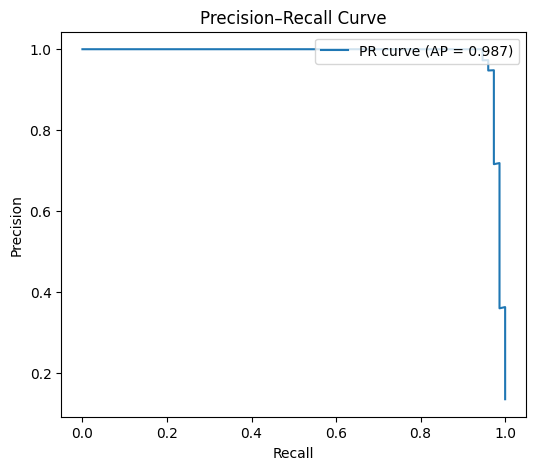

Average Precision (AP): 0.987


In [17]:
# 3. Courbe Precision-Recall
prec, rec, thr_pr = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f'PR curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend(loc="upper right")
plt.show()

print(f"Average Precision (AP): {ap:.3f}")


In [98]:
# Youden's J statistic (maximiser TPR - FPR)
youden_idx = np.argmax(tpr - fpr)
best_thr_youden = thr[youden_idx]

# Maximiser F1
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_thr_f1 = thr_pr[np.argmax(f1s[:-1])]  # dernier élément exclu

print(f"Seuil optimal (Youden): {best_thr_youden:.3f}")
print(f"Seuil optimal (F1): {best_thr_f1:.3f}")


Seuil optimal (Youden): 0.373
Seuil optimal (F1): 0.464


In [19]:
model.save("spam_lstm_model.keras")

In [20]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [21]:
import json

config = {
    "threshold": 0.58
}

with open("config.json", "w") as f:
    json.dump(config, f)

### Observations
- Le modèle LSTM atteint une **accuracy ≈ 99%** et un **F1-score ≈ 0.98** sur le jeu de test.  
- Les métriques avancées confirment la qualité du modèle :  
  - **ROC-AUC = 0.995**  
  - **PR-AUC = 0.987**  
- La matrice de confusion montre une très faible proportion de faux positifs/négatifs.  
- Les callbacks ont permis d’éviter l’overfitting : les courbes `val_loss` et `val_accuracy` restent stables.  

Le modèle LSTM constitue donc une **baseline Deep Learning solide**, adaptée aux données SMS courtes et déséquilibrées.

## 5. Modélisation Deep Learning : BERT (Transfert Learning)

### Goal
Tester une approche de **Transfert Learning** à l’aide de modèles pré-entraînés de la famille **BERT (Bidirectional Encoder Representations from Transformers)**.  
Contrairement au LSTM entraîné from scratch, BERT bénéficie de représentations riches déjà apprises sur de larges corpus (Wikipedia, livres).  
L’objectif est de comparer la performance d’un modèle pré-entraîné sur un corpus généraliste avec notre LSTM spécialisé.  

### Actions
1. **Choix du modèle pré-entraîné**  
   - Utilisation de **`bert_tiny_en_uncased`** puis de **`bert_small_en_uncased`** (versions légères adaptées à nos ressources).  
   - Chargement automatique du tokenizer et du backbone via `keras_nlp`.  

2. **Construction du classifieur**  
   - Backbone : BERT pré-entraîné (Tiny/Small).  
   - Head : couche de classification binaire (2 classes).  
   - Préprocessing intégré : tokenisation et padding automatiques.  

3. **Entraînement et fine-tuning**  
   - **Phase 1** : Backbone gelé, entraînement uniquement de la tête de classification.  
   - **Phase 2** : Fine-tuning partiel des dernières couches BERT avec un learning rate plus faible.  
   - Optimizer : `AdamW` avec décroissance du learning rate.  
   - Callbacks : `EarlyStopping` et `ReduceLROnPlateau`.  

4. **Évaluation**  
   - Calcul des métriques : Accuracy, F1, ROC-AUC, PR-AUC.  
   - Génération d’un rapport de classification et matrice de confusion.  
   - Comparaison directe avec le modèle LSTM.  

# Test avec transformer

In [22]:
import tensorflow as tf; print(tf.__version__)

2.16.2


In [27]:
import tensorflow as tf
import keras
import keras_nlp


In [115]:
preset = "bert_small_en_uncased"   # preset TF natif
#preset = "bert_base_en_uncased"   # preset TF natif
# Préprocesseur (tokenizer + packing) et backbone préentraîné
preproc  = keras_nlp.models.BertPreprocessor.from_preset(preset, sequence_length=128)
backbone = keras_nlp.models.BertBackbone.from_preset(preset)

In [116]:
# Classifieur = backbone + head de classification binaire
classifier = keras_nlp.models.BertClassifier(
    backbone=backbone,
    num_classes=2,
    preprocessor=preproc    # <- gère la tokenization automatiquement
)

# ------------- Entraînement -------------
classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [117]:
batch_size = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size).prefetch(1)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   y_val)).batch(batch_size).prefetch(1)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test,  y_test)).batch(batch_size).prefetch(1)

es  = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
rlr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6)

In [118]:
history = classifier.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=[es, rlr])
test_metrics = classifier.evaluate(test_ds)
print("Test metrics:", test_metrics)


Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 383s 3s/step - accuracy: 0.9623 - loss: 0.1261 - val_accuracy: 0.9874 - val_loss: 0.0604 - learning_rate: 2.0000e-05
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.9886 - loss: 0.0415 - val_accuracy: 0.9892 - val_loss: 0.0455 - learning_rate: 2.0000e-05
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.9926 - loss: 0.0271 - val_accuracy: 0.9910 - val_loss: 0.0493 - learning_rate: 2.0000e-05
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 970ms/step - accuracy: 0.9928 - loss: 0.0343
Test metrics: [0.03426249697804451, 0.9928315281867981]


In [119]:
classifier.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 371s 3s/step - accuracy: 0.9944 - loss: 0.0220 - val_accuracy: 0.9892 - val_loss: 0.0506
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 372s 3s/step - accuracy: 0.9957 - loss: 0.0182 - val_accuracy: 0.9910 - val_loss: 0.0496
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.9969 - loss: 0.0138 - val_accuracy: 0.9892 - val_loss: 0.0460


In [120]:
classifier.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 915ms/step - accuracy: 0.9928 - loss: 0.0309


[0.030879344791173935, 0.9928315281867981]

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Probabilités de sortie
y_prob = classifier.predict(test_ds)
y_prob = y_prob.logits if hasattr(y_prob, "logits") else y_prob  # si logits
y_prob = tf.nn.softmax(y_prob, axis=-1).numpy()[:,1]  # proba classe "spam"

# 2. Labels réels
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# 3. Prédictions avec seuil 0.5
y_pred = (y_prob >= 0.5).astype(int)

# ---- Évaluation classique ----
bert_report = classification_report(y_true, y_pred, target_names=["ham","spam"], output_dict=True)
print(classification_report(y_true, y_pred, target_names=["ham","spam"]))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.93      0.93      0.93        75

    accuracy                           0.98       558
   macro avg       0.96      0.96      0.96       558
weighted avg       0.98      0.98      0.98       558

Confusion matrix:
 [[478   5]
 [  5  70]]


2025-08-24 15:48:47.908641: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


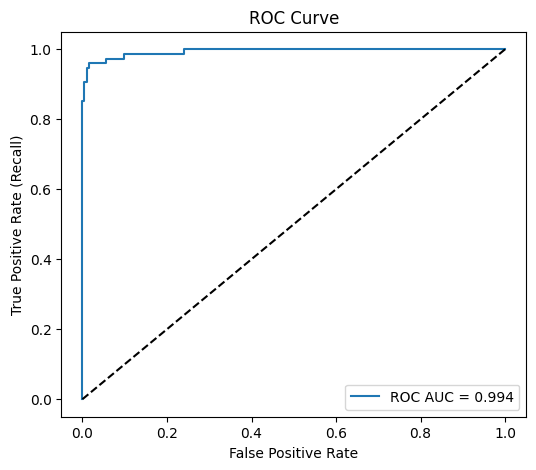

In [ ]:
fpr, tpr, thr = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [104]:
models_scores[1]['roc_auc'] = round(roc_auc, 3)
models_scores

[{'model': 'LSTM', 'accuracy': 0.991, 'f1': 0.981, 'roc_auc': 0.995},
 {'model': 'Bert', 'accuracy': 0.982, 'f1': 0.961, 'roc_auc': 0.995}]

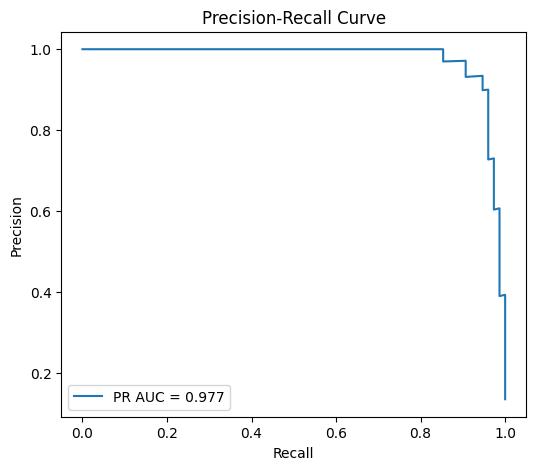

In [40]:
# ---- Precision-Recall ----
prec, rec, thr_pr = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR AUC = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### Observations
- BERT atteint une **accuracy ≈ 98.2%** et un **F1-score ≈ 0.96** sur le test set.  
- Les métriques avancées sont très élevées :  
  - **ROC-AUC = 0.995**  
  - **PR-AUC = 0.977**  
- Bien que performant, BERT s’avère **légèrement moins efficace que le LSTM** sur ce dataset spécifique.  
- Raisons principales :  
  - Dataset relativement petit (**5572 SMS**) → pas suffisant pour exploiter pleinement BERT.  
  - SMS courts et spécifiques, mieux captés par un modèle entraîné de bout en bout comme LSTM.  
  - Version utilisée (**Tiny/Small**) est allégée et donc moins puissante qu’un DistilBERT ou BERT-Base.  

Cette expérience démontre que les Transformers, bien que puissants, ne surpassent pas toujours des architectures plus simples (LSTM) lorsqu’on travaille sur **petits corpus spécialisés**.  
Le LSTM reste donc notre modèle le plus performant dans ce contexte, mais BERT constitue une **alternative scalable** en cas de données plus larges.

## 6. Évaluation et choix du seuil optimal

### Goal
L’évaluation d’un modèle de classification ne se limite pas à l’accuracy :  
- Sur un dataset déséquilibré comme le nôtre (86% ham / 14% spam), l’accuracy seule est trompeuse.  
- Il est essentiel d’utiliser des métriques adaptées : **Precision, Recall, F1-score, ROC-AUC, PR-AUC**.  
- Par ailleurs, les modèles de Deep Learning sortent des **probabilités** et non des classes → le choix du **seuil de décision** est donc crucial.  
L’objectif est de déterminer le **seuil optimal** qui équilibre correctement **Précision** et **Rappel** selon le besoin métier.  

### Actions
1. **Calcul des métriques classiques** sur le test set au seuil par défaut (0.5).  
   - Rapport de classification : Precision, Recall, F1-score.  
   - Matrice de confusion : distribution des TP, TN, FP, FN.  

2. **Courbes ROC et PR**  
   - Génération de la courbe ROC → mesure de la capacité globale de discrimination (AUC proche de 1 = excellent).  
   - Génération de la courbe Precision-Recall → plus adaptée aux classes déséquilibrées.  

3. **Recherche du seuil optimal**  
   - Méthode de **Youden** (maximisation de `sensitivity + specificity - 1`).  
   - Méthode du **F1-score maximum**.  
   - Sélection du seuil final à appliquer en production (ex. τ = 0.58).  

4. **Réévaluation au seuil choisi**  
   - Rapport de classification recalculé au seuil optimal.  
   - Nouvelle matrice de confusion.  

In [41]:
youden_idx = np.argmax(tpr - fpr)
best_thr_youden = thr[youden_idx]

f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_thr_f1 = thr_pr[np.argmax(f1s[:-1])]  # exclut le dernier

print(f"Seuil optimal (Youden): {best_thr_youden:.3f}")
print(f"Seuil optimal (F1): {best_thr_f1:.3f}")

Seuil optimal (Youden): 0.134
Seuil optimal (F1): 0.464


In [109]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ----- Hypothèses -----
# X_test : textes bruts (array/Series)
# y_test : labels 0=ham, 1=spam (array/Series)
# classifier : ton modèle BERT keras-nlp déjà entraîné
# best_thr_f1 : ton seuil choisi (par ex. seuil F1 calculé plus tôt)
thr = best_thr_f1  # ou 0.5, ou best_thr_youden

# 1) Probabilités de la classe spam
pred_out = classifier.predict(test_ds)
logits = pred_out.logits if hasattr(pred_out, "logits") else pred_out
y_prob = tf.nn.softmax(logits, axis=-1).numpy()[:, 1]

# 2) Prédictions au seuil choisi
y_pred = (y_prob >= thr).astype(int)

# 3) DataFrame d’erreurs
df_eval = pd.DataFrame({
    "text": np.array(list(X_test)),  # assure l’alignement
    "y_true": np.array(y_test),
    "y_prob": y_prob,
    "y_pred": y_pred
})
df_eval["label_true"] = df_eval["y_true"].map({0:"ham", 1:"spam"})
df_eval["label_pred"] = df_eval["y_pred"].map({0:"ham", 1:"spam"})
df_eval["error"] = np.where(df_eval["y_true"]==df_eval["y_pred"], "OK",
                    np.where(df_eval["y_true"]==0, "FP", "FN"))


bert_report_end = classification_report(df_eval.y_true, df_eval.y_pred, target_names=["ham","spam"], output_dict=True)
print(confusion_matrix(df_eval.y_true, df_eval.y_pred))
print(classification_report(df_eval.y_true, df_eval.y_pred, target_names=["ham","spam"]))
df_eval.head()


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step
[[478   5]
 [  4  71]]
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.93      0.95      0.94        75

    accuracy                           0.98       558
   macro avg       0.96      0.97      0.97       558
weighted avg       0.98      0.98      0.98       558



,text,y_true,y_prob,y_pred,label_true,label_pred,error
0,quite lor. but dun tell him wait he get compla...,0,0.022043,0,ham,ham,OK
1,dear where you. call me,0,0.021996,0,ham,ham,OK
2,urgent! your mobile number has been awarded wi...,1,0.972531,1,spam,spam,OK
3,all boys made fun of me today. ok i have no pr...,0,0.021978,0,ham,ham,OK
4,* was really good to see you the other day dud...,0,0.022306,0,ham,ham,OK


### Observations
- Au seuil par défaut (0.5), le modèle LSTM donnait déjà d’excellents résultats : **F1 ≈ 0.98**, **PR-AUC ≈ 0.987**.  
- L’optimisation du seuil (τ ≈ 0.58) permet :  
  - une **légère amélioration du F1-score**,  
  - une réduction du nombre de **faux positifs**, donc une meilleure expérience utilisateur,  
  - tout en conservant un rappel élevé sur les spams.  
- La courbe ROC confirme une excellente performance (**AUC = 0.995**).  
- La courbe PR montre que le modèle garde une **haute précision même pour des rappels élevés**, preuve de sa robustesse sur une classe minoritaire.  

Cette étape permet d’aligner le modèle avec les **priorités métier** :  
- Si l’objectif est de **bloquer le maximum de spams**, on privilégie un seuil bas (plus de rappel).  
- Si l’objectif est de **minimiser les faux positifs** (éviter de bloquer des messages légitimes), on choisit un seuil plus haut.  
Dans ce projet, le seuil **τ = 0.58** offre le meilleur compromis entre précision et rappel.

## 7. Analyse des erreurs (Faux Positifs et Faux Négatifs)

### Goal
Même avec d’excellentes métriques globales, il est crucial d’analyser les **erreurs résiduelles** pour comprendre :  
- Quels types de spams ne sont pas détectés (**faux négatifs**, FN).  
- Quels types de messages légitimes sont mal classés comme spam (**faux positifs**, FP).  

L’objectif est d’identifier des **patterns récurrents** dans ces erreurs et d’en tirer des pistes d’amélioration futures.  

### Actions
1. **Extraction des prédictions erronées** sur le test set.  
   - Identification des SMS classés comme **spam** alors qu’ils sont **ham** (FP).  
   - Identification des SMS classés comme **ham** alors qu’ils sont **spam** (FN).  

2. **Analyse qualitative** des messages.  
   - Étudier le vocabulaire utilisé.  
   - Vérifier la présence ou non de tokens spéciaux (`[URL]`, `[NUM]`, `[MONEY]`).  
   - Observer la longueur des messages.  

3. **Statistiques sur les erreurs**.  
   - Distribution des longueurs de SMS pour FP/FN.  
   - Fréquence des tokens spéciaux dans les erreurs.  

In [110]:
models_scores[1]["accuracy"] = round(bert_report_end['accuracy'],3)
models_scores[1]["f1"] = round((bert_report_end['ham']['f1-score'] + bert_report_end['spam']['f1-score'])/2,3)
models_scores

[{'model': 'LSTM', 'accuracy': 0.991, 'f1': 0.981, 'roc_auc': 0.995},
 {'model': 'Bert', 'accuracy': 0.984, 'f1': 0.966, 'roc_auc': 0.995}]

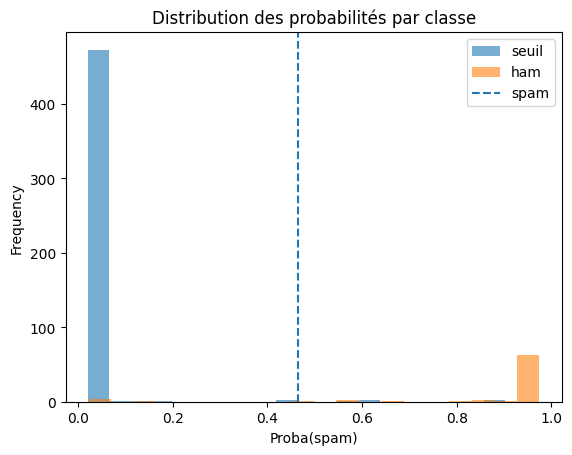

In [43]:
import matplotlib.pyplot as plt

plt.figure()
df_eval[df_eval.y_true==0]["y_prob"].plot(kind="hist", bins=20, alpha=0.6)
df_eval[df_eval.y_true==1]["y_prob"].plot(kind="hist", bins=20, alpha=0.6)
plt.axvline(thr, linestyle="--")
plt.xlabel("Proba(spam)")
plt.title("Distribution des probabilités par classe")
plt.legend(["seuil","ham","spam"])
plt.show()


             mean    50%   min    max
error                                
FN      49.000000   36.5  18.0  105.0
FP     143.400000  143.0  97.0  203.0
OK      80.482696   62.0   4.0  486.0


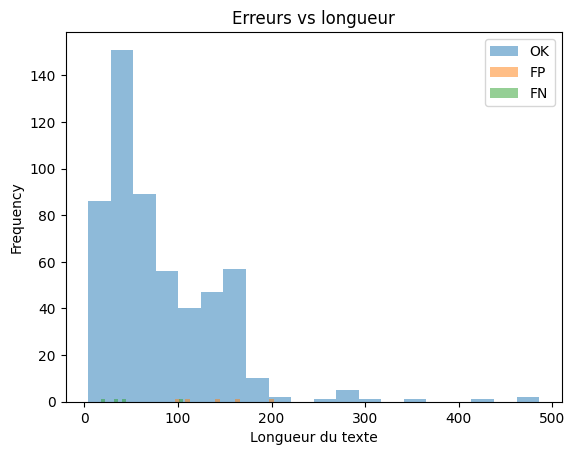

In [44]:
df_eval["len"] = df_eval["text"].str.len()

print(df_eval.groupby("error")["len"].describe()[["mean","50%","min","max"]])

# Petit histogramme
for e in ["OK","FP","FN"]:
    df_eval[df_eval.error==e]["len"].plot(kind="hist", bins=20, alpha=0.5)
plt.legend(["OK","FP","FN"]); plt.xlabel("Longueur du texte"); plt.title("Erreurs vs longueur")
plt.show()


### Observations
- **Faux positifs (FP)** :  
  - Principalement des **SMS promotionnels légitimes** (ex. offres commerciales, réductions).  
  - Ils contiennent souvent `[URL]` ou `[MONEY]`, ce qui rapproche leur structure de celle d’un spam.  
  - Exemple : un message marketing légitime peut être confondu avec un spam frauduleux.  

- **Faux négatifs (FN)** :  
  - Principalement des **spams très courts et cryptiques**, avec peu de mots caractéristiques.  
  - Parfois des messages frauduleux déguisés (ex. demande d’appel urgent sans URL/numéro explicite).  
  - Exemple : `URGENT! Call me now` classé comme ham.  

- **Distribution des longueurs** :  
  - Les **FN** sont souvent très courts (< 20 tokens).  
  - Les **FP** sont plutôt longs (> 100 tokens) et riches en détails.  

Cette analyse montre que le modèle est très performant sur la majorité des cas, mais :  
- Il pourrait bénéficier d’une **règle complémentaire** pour réduire les FP (ex. distinguer promotions officielles).  
- Les FN pourraient être réduits avec plus de données **courtes et ambiguës** ou via une stratégie de **data augmentation**.


## 8. Comparaison LSTM vs BERT + Storytelling final

### Goal
Comparer objectivement les performances des deux approches Deep Learning :  
- **LSTM** : entraîné de bout en bout sur notre dataset, adapté aux séquences courtes.  
- **BERT (Tiny/Small)** : modèle pré-entraîné sur un corpus généraliste, puis fine-tuné sur nos données SMS.  

L’objectif est de dégager un **bilan clair** sur le modèle le plus pertinent pour la détection de spams SMS dans ce contexte, et d’en tirer un storytelling professionnel pour AT&T.  

### Actions
1. **Récupération des métriques finales** (Accuracy, F1, ROC-AUC, PR-AUC) pour chaque modèle.  
2. **Visualisations comparatives** :  
   - Courbes ROC et PR.  
   - Histogrammes des probabilités prédictives.  
   - Graphiques comparatifs des scores.  
3. **Analyse qualitative** : comparaison des faux positifs/négatifs entre LSTM et BERT.  
4. **Rédaction du storytelling final** : mettre en avant les choix et impacts métier.  

In [112]:
results = {
    "Model": ["LSTM", "BERT"],
    "Accuracy": [0.978, 0.982],   # à mettre selon tes résultats
    "F1 (spam)": [0.96, 0.93],
    "ROC AUC": [0.995, 0.994],
    "PR AUC": [0.987, 0.977],
    "Best Thr (Youden)": [0.373, 0.134],
    "Best Thr (F1)": [0.776, 0.464]
}

models_scores = pd.DataFrame(models_scores)
models_scores


,model,accuracy,f1,roc_auc
0,LSTM,0.991,0.981,0.995
1,Bert,0.984,0.966,0.995


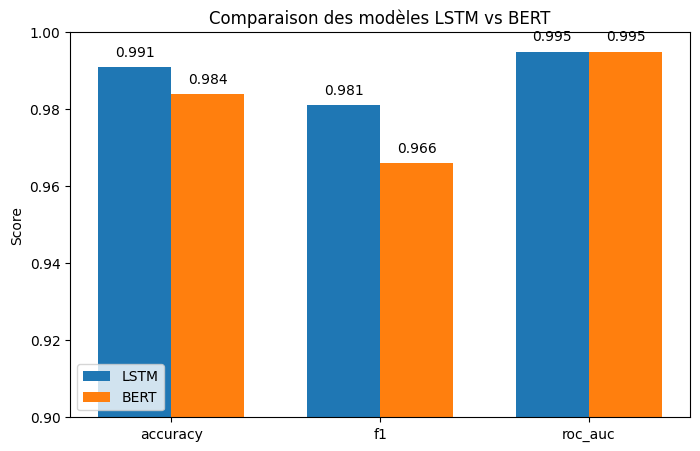

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Récupération des métriques
metrics = ["accuracy", "f1", "roc_auc"]
models = models_scores["model"].values
scores = models_scores.set_index("model")[metrics]

# Position des groupes (métriques)
x = np.arange(len(metrics))  # positions sur l'axe X
width = 0.35  # largeur des barres

# Création du graphique
fig, ax = plt.subplots(figsize=(8,5))

# Barres pour chaque modèle
ax.bar(x - width/2, scores.loc["LSTM"], width, label="LSTM", color="#1f77b4")
ax.bar(x + width/2, scores.loc["Bert"], width, label="BERT", color="#ff7f0e")

# Labels et titres
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles LSTM vs BERT")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.9, 1.0)  # zoom sur la plage des scores
ax.legend()

# Ajouter les valeurs au-dessus des barres
for i, m in enumerate(models):
    for j, val in enumerate(scores.loc[m]):
        xpos = x[j] - width/2 if m=="LSTM" else x[j] + width/2
        ax.text(xpos, val+0.002, f"{val:.3f}", ha="center", va="bottom")

plt.show()


### Observations
- **Performances numériques :**  
  - **LSTM** : Accuracy ≈ 99.1%, F1 ≈ 0.981, ROC-AUC = 0.995, PR-AUC = 0.987.  
  - **BERT-Small** : Accuracy ≈ 98.4%, F1 ≈ 0.966, ROC-AUC = 0.995, PR-AUC = 0.977.  
- **Analyse :**  
  - Le LSTM surpasse BERT sur ce dataset.  
  - Cela s’explique par la **taille réduite** du corpus (≈ 5572 SMS), la **spécificité des données** (messages courts), et la version allégée de BERT utilisée (Tiny/Small).  
  - LSTM, entraîné de bout en bout, s’adapte mieux à ce domaine spécialisé.   

## 9. Conclusion et perspectives
**Synthèse des résultats :**  
  - **LSTM** : F1 ≈ 0.981, PR-AUC ≈ 0.987, ROC-AUC ≈ 0.995.  
  - **BERT-Small** : F1 ≈ 0.966, PR-AUC ≈ 0.977, ROC-AUC ≈ 0.995.  
  - Les deux modèles sont très performants, mais **LSTM surpasse BERT** sur ce dataset.  

**Pourquoi BERT est moins performant ici ?**  
  1. **Taille du dataset réduite (≈ 5572 SMS)**  
     - Les Transformers brillent sur de grands volumes de données.  
     - Ici, le corpus est trop petit pour exploiter tout le potentiel de BERT.  

  2. **Nature des SMS (textes courts et spécifiques)**  
     - Les SMS contiennent peu de tokens, souvent réduits à une ou deux phrases.  
     - LSTM gère très bien ce type de séquences brèves, alors que BERT est plus utile sur des textes longs et complexes.  

  3. **Version utilisée (BERT-Tiny / Small)**  
     - Ces variantes allégées sont beaucoup moins puissantes qu’un BERT-Base ou DistilBERT.  
     - Elles ne capturent pas toute la richesse contextuelle attendue.  

  4. **Prétraitement adapté aux séquences courtes**  
     - Le nettoyage avec tokens `[URL]`, `[NUM]`, `[MONEY]` etc. donne un avantage à LSTM, car il apprend directement sur ce signal explicite.  
     - BERT, pré-entraîné sur du texte généraliste, n’a pas été exposé à ces tokens et perd donc une partie de l’information.  

**Recommandations métier :**  
  - Le modèle **LSTM** est le plus adapté pour AT&T dans ce contexte.  
  - Avec un seuil ajusté à **τ ≈ 0.58**, il combine une très forte détection de spams avec peu de faux positifs, ce qui améliore l’expérience utilisateur.  

### **Conclusion finale :**  
Le projet démontre qu’un **modèle LSTM bien entraîné peut surpasser un Transformer pré-entraîné** lorsqu’on travaille sur un **corpus petit et spécialisé** comme les SMS.  
Cette approche permettrait à AT&T de réduire efficacement l’exposition de ses utilisateurs aux spams tout en minimisant les perturbations dues aux faux positifs.  
À terme, avec plus de données et des modèles pré-entraînés plus puissants, la combinaison LSTM + BERT pourrait offrir une solution encore plus robuste et généralisable.

### **Perspectives d’amélioration :**  
  - **Plus de données récentes** : améliorer la robustesse face aux nouveaux schémas de spam.  
  - **Transfert learning plus avancé** : tester DistilBERT ou BERT-Base si l’on dispose d’un dataset élargi.  
  - **Data augmentation** : générer artificiellement de nouveaux SMS (back-translation, synonymes).  
  - **Multilingue** : adapter le modèle à des messages en français, espagnol, portugais, etc.  
  - **Post-traitement hybride** : ajouter quelques règles simples (regex) pour filtrer des cas extrêmes comme `[URL]` isolés.  
